# OpenQuake



# 0. Objectives

* Use the **USGS ComCat** database to retrieve source parameters required to implement Ground Motion Models (GMMs) in Engineering Practice
* Manipulate and visualize rupture model file formats using PyGMT scripts
* Calculate **distance metrics** required in GMMs for different rupture models using **OpenQuake** engine
* Estimate ground motion Intensity Measures (IM) at given locations and their corresponding uncertainty using GMMs through **OpenQuake** hazard library
* Calculate the probability of exceeding a ground motion IM at a given site of interest
* Utilize **Next Generation Attanuation (NGA) flatfiles** to retrieve ground motion IM and metadata for source, path, and site conditions of specific events
* Examine the performance of GMMs by comparing model predictions with observed ground motions

# 1. Installing openquake.engine

<div style="border: 1px solid #e0e0e0; border-radius: 2px; padding: 5px; font-family: sans-serif; background-color: #fafafa;">
  <div style="background-color: #f5f5f5; border: 1px solid #e0e0e0; border-radius: 4px; padding: 12px; font-family: monospace; position: relative; line-height: 1.6;">
    <code style="color: #212121;">conda create --prefix ./.env --channel conda-forge python=3.10 "pygmt<=0.17.0"</code><br>
    <code style="color: #212121;">Cmd + Shift + P follow by Python: Select Interpreter followed by select path to the local project </code><br>
    <code style="color: #212121;">conda activate ./env</code><br>
    <code style="color: #212121;">pip install openquake.engine </code><br>
    <code style="color: #212121;">pip install ipykernel</code><br>
    <code style="color: #212121;">pip install openpyxl</code><br>  
    <code style="color: #212121;">pip install geopandas</code><br>
    <code style="color: #212121;">pip install fiona</code><br>    
    <code style="color: #212121;">pip install scipy</code><br>   
  </div>
</div>

In [1]:
import pygmt
import pandas as pd
pygmt.show_versions()

PyGMT information:
  version: v0.13.0
System information:
  python: 3.10.21 | packaged by conda-forge | (main, Aug 21 2026, 22:37:53) [Clang 19.1.7 ]
  executable: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/4_OpenQuake/env/bin/python
  machine: macOS-26.6.2-arm64-arm-64bit
Dependency information:
  numpy: 2.2.6
  pandas: 2.3.3
  xarray: 2025.6.1
  netCDF4: 1.7.4
  packaging: 26.3
  contextily: None
  geopandas: 1.1.4
  IPython: 8.39.0
  rioxarray: None
  gdal: None
  ghostscript: 10.07.1
GMT library information:
  version: 6.6.0
  padding: 2
  share dir: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/4_OpenQuake/env/share/gmt
  plugin dir: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/4_OpenQuake/env/lib/gmt/plugins
  library path: /Users/dfbarbag/Documents/Projects/00_CE746_Workshops/4_OpenQuake/env/lib/libgmt.dylib
  cores: 10
  grid layout: rows
  image layout: 
  binary version: 6.6.0


# 2. Event: $M_W7.6$ Chi-Chi, Taiwan Earthquake

Information about the event **USGS**: https://earthquake.usgs.gov/earthquakes/eventpage/usp0009eq0/executive


<table>
  <tr>
    <td><img src="https://upload.wikimedia.org/wikipedia/commons/9/9c/990921중앙119구조본부_대만_921_대지진_출동1.jpg?utm_source=en.wikipedia.org&utm_campaign=index&utm_content=original" alt="Image 1" width="200"></td>
    <td><img src="https://www.eas.slu.edu/eqc/eqc_photos/1999TaiwanEQ/images/001b.jpg" alt="Image 2" width="400"></td>
    <td><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRy8P_7_JFrSvQmqWfH9yah3Gg8lS9K_AtCK8KNoY4XkVSmTFFGMhguM4M&s=10" alt="Image 2" width="200"></td>
  </tr>
  <tr>
    <td><img src="https://research.engineering.ucdavis.edu/gpa/wp-content/uploads/sites/43/2015/02/Rupture-in-track-field.jpg" alt="Image 3" width="250"></td>
    <td><img src="https://cdn.britannica.com/76/139776-050-7256BFE8/Chi-chi-Temple-earthquake-Taiwan-1999.jpg" alt="Image 4" width="400"></td>
    <td><img src="https://research.engineering.ucdavis.edu/gpa/wp-content/uploads/sites/43/2015/02/Bridge-and-waterfall.jpg" alt="Image 3" width="260"></td>
  </tr>
</table>

In [2]:
import pandas as pd
event = pd.read_csv("data/events_Taiwan.csv")
event.head()

,event_name,longitude,latitude,depth,strike,dip,rake,magnitude,plot_longitude,plot_latitude
0,Mw7.6 Chi-Chi,120.813,23.834,10.0,220.0,75.00,90.00,7.58,120.2,25.0
1,Mw6.9 Taitung,121.200,23.140,10.0,102.9,66.52,156.72,6.90,122.0,23.5


In [3]:
df_NGAW2 = pd.read_excel("data/Updated_NGAW2_Flatfile_Vertical_5percentdamping.xlsx")
print(df_NGAW2.head())

/Users/dfbarbag/Documents/Projects/00_CE746_Workshops/4_OpenQuake/env/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


   Record Sequence Number  EQID     Earthquake Name  YEAR  MODY  HRMN  \
0                       1     1  Helena, Montana-01  1935  1031  1838   
1                       2     2  Helena, Montana-02  1935  1031  1918   
2                       3     3         Humbolt Bay  1937   207   442   
3                       4     4  Imperial Valley-01  1938   606   242   
4                       5     5  Northwest Calif-01  1938   912   610   

         Station Name  Station Sequence Number Station ID  No.  \
0     Carroll College                      197            2022   
1     Helena Fed Bldg                      198            2229   
2  Ferndale City Hall                      133            1023   
3  El Centro Array #9                       75             117   
4  Ferndale City Hall                      133            1023   

   Earthquake Magnitude  ... Instrument Nat. Freq.  Instrument Damping  \
0                   6.0  ...                -999.0              -999.0   
1               

In [7]:
print(df_NGAW2.columns.tolist())

['Record Sequence Number', 'EQID', 'Earthquake Name', 'YEAR', 'MODY', 'HRMN', 'Station Name', 'Station Sequence Number', 'Station ID  No.', 'Earthquake Magnitude', 'Magnitude Type', 'Magnitude Uncertainty: Kagan Model', 'Magnitude Uncertainty: Statistical', 'Magnitude Sample Size', 'Magnitude Uncertainty: Study Class', 'Mo (dyne.cm)', 'Strike (deg)', 'Dip (deg)', 'Rake Angle (deg)', 'Mechanism Based on Rake Angle', 'P-plunge (deg)', 'P-trend (deg)', 'T-plunge (deg)', 'T-trend (deg)', 'Hypocenter Latitude (deg)', 'Hypocenter Longitude (deg)', 'Hypocenter Depth (km)', 'Coseismic Surface Rupture: 1=Yes; 0=No;    -999=Unknown', 'Coseismic Surface Rupture (Including Inferred)', 'Basis for Inference of Surface Rupture', 'Finite Rupture Model: 1=Yes;  0=No', 'Depth to Top Of Fault Rupture Model', 'Fault Rupture Length for Calculation of Ry (km)', 'Fault Rupture Width (km)', 'Fault Rupture Area (km^2)', 'Avg Fault Disp (cm)', 'Rise Time (s)', 'Avg Slip Velocity (cm/s)', 'Static Stress Drop (ba

In [5]:
df_chichi = df_NGAW2[df_NGAW2['Earthquake Name']=="Chi-Chi, Taiwan"]
df_chichi.head()

,Record Sequence Number,EQID,Earthquake Name,YEAR,MODY,HRMN,Station Name,Station Sequence Number,Station ID No.,Earthquake Magnitude,...,Instrument Nat. Freq.,Instrument Damping,Instrument Type,Unused Column.5,Spectra Quality Flag,Late S-trigger,Late P-trigger,Idirectivity,Tp,Ry 2
1177,1178,137,"Chi-Chi, Taiwan",1999,920,-999,ALS,595,-999,7.62,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0000,-47.955050
1178,1179,137,"Chi-Chi, Taiwan",1999,920,-999,CHK,628,-999,7.62,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0000,-74.115220
1179,1180,137,"Chi-Chi, Taiwan",1999,920,-999,CHY002,630,-999,7.62,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0000,-35.504792
1180,1181,137,"Chi-Chi, Taiwan",1999,920,-999,CHY004,631,-999,7.62,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0000,-51.521019
1181,1182,137,"Chi-Chi, Taiwan",1999,920,-999,CHY006,632,-999,7.62,...,-999.0,-999.0,-999,-999,0,-999,-999,1,2.5704,-49.363629


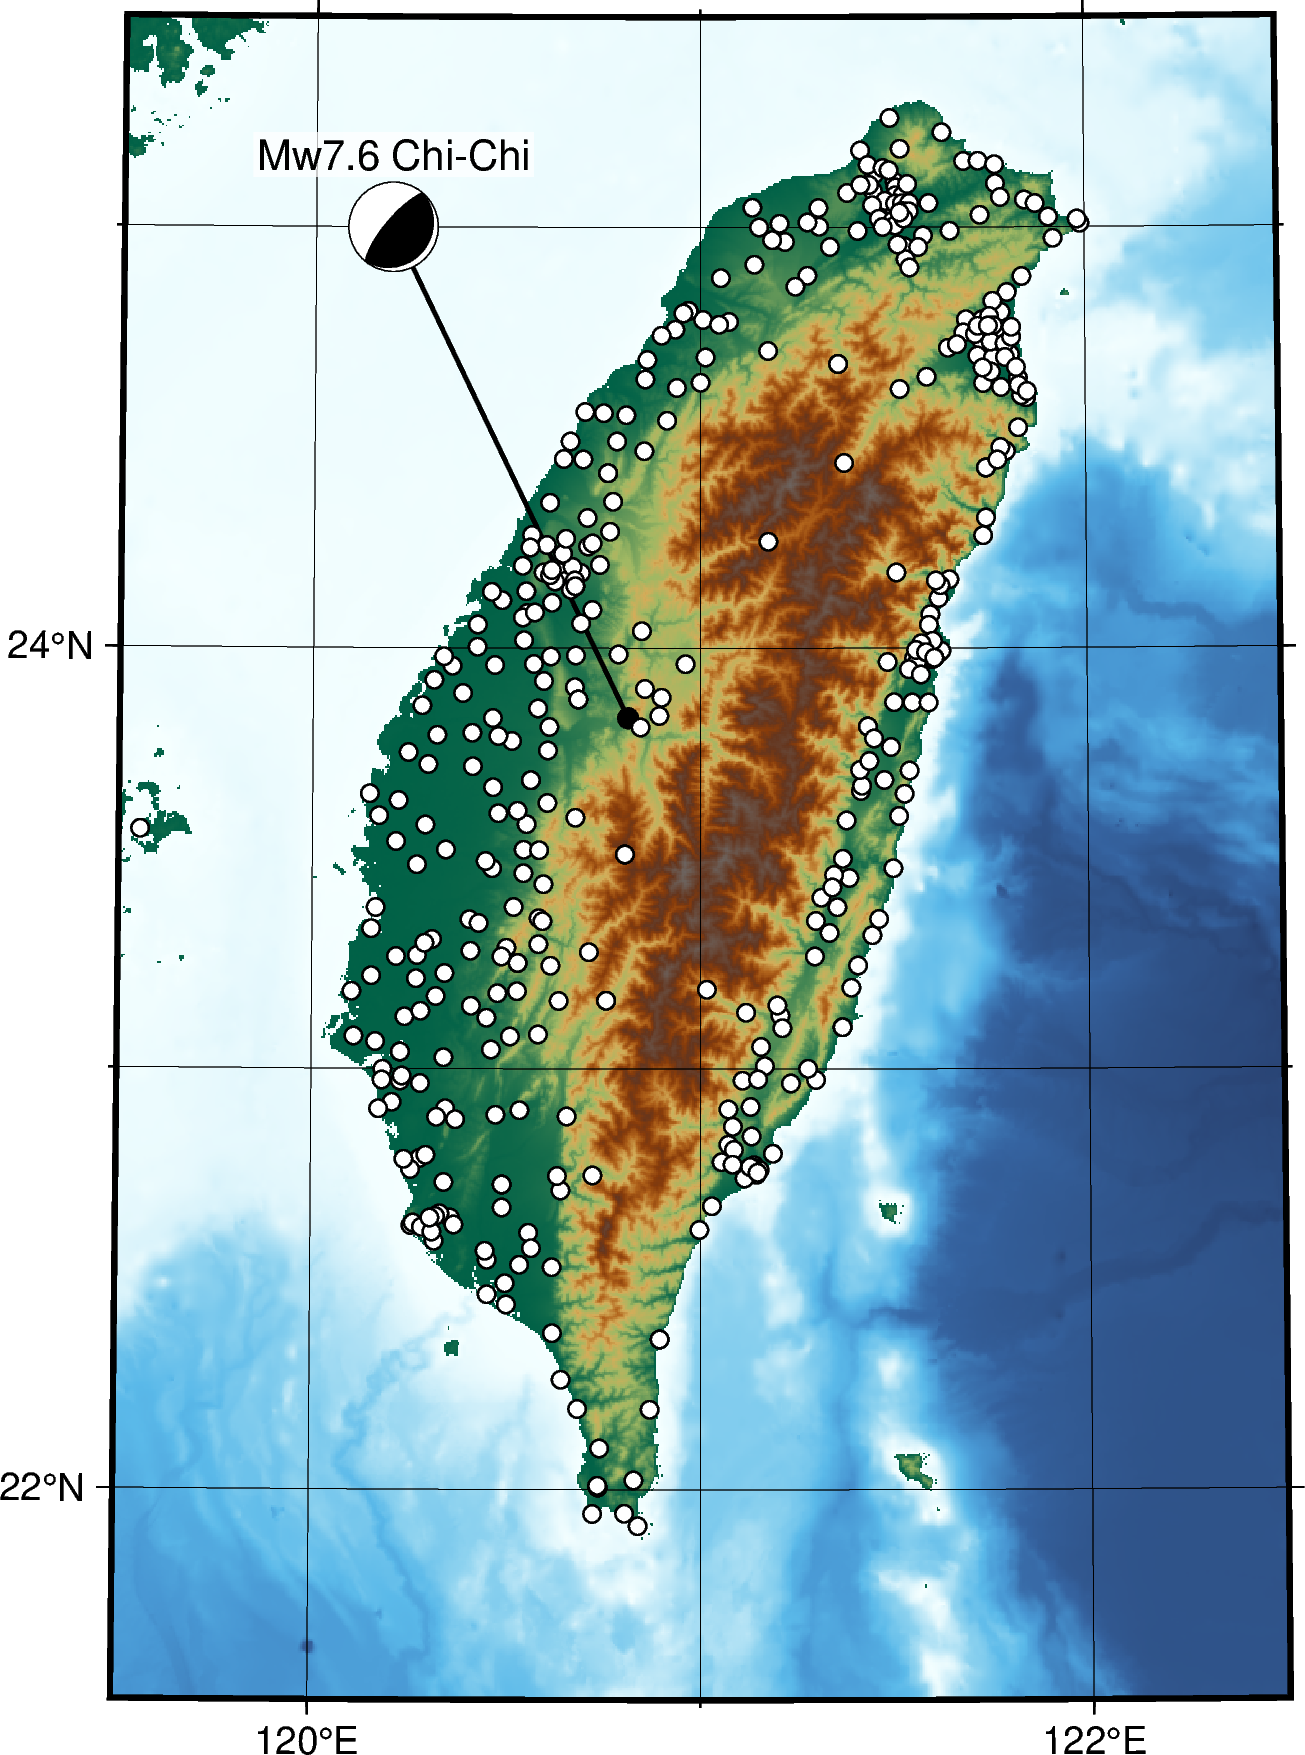

In [6]:
fig = pygmt.Figure()
region = [119.5, 122.5, 21.5, 25.5]
proj = "T121/23.5/10c"

grid = pygmt.datasets.load_earth_relief(resolution="15s", region=region)
pygmt.makecpt(cmap="geo", series=[-8000, 7000, 500], continuous=True, output="data/eleva.cpt")

fig.grdimage(grid=grid, region=region, projection=proj, cmap="data/eleva.cpt")

with pygmt.config(MAP_GRID_PEN="0.1p,black"):
    fig.basemap(frame=["WSne", "a2f1g1"])

fig.meca(spec=event.iloc[0,0:].to_dict(), scale="0.5c+f10p", labelbox="white@30", offset="+p1p,black+s0.15c")
fig.plot(x=df_chichi["Station Longitude"], y=df_chichi["Station Latitude"], style="c0.15c",  fill="white", pen="0.5p,black")

fig.show()

# 3. Ground Motion Models (GMMs): NGA-West2


| **Parameter**         | **Symbol**  | **Units**  | **BSSA14** | **CY14** | 
| :-------              | :------:    | :------:   |  :------:  | :------: | 
| **Source parameters** |         
| Moment magnitude           |  $M_W$      | -     | <input type="checkbox" checked disabled>  | <input type="checkbox" checked disabled> | 
| Depth-to-top of rupture    |  $Z_{tor}$  | km    |  -                                        | <input type="checkbox" checked disabled> | 
| Fault dip                  |  $\delta$   | °     |  -                                        | <input type="checkbox" checked disabled> | 
| Rake (to define style of faulting)   | $\lambda$ | °  |  <input type="checkbox" checked disabled> | <input type="checkbox" checked disabled> | 
| **Path parameters**   |
| Closest distance to rupture plane <br> (rupture distance)                                       | $R_{rup}$ | km   | - | <input type="checkbox" checked disabled> | 
| Horizontal distance to surface<br> projection of the rupture<br> (Joyner-Boore distance)        | $R_{JB}$  | km   | <input type="checkbox" checked disabled> | <input type="checkbox" checked disabled> | 
| Horizontal distance to edge<br> of the rupture measured perpendicular <br>to the fault strike   | $R_{X}$   | km   | - | <input type="checkbox" checked disabled> | 
| Hanging-wall flag <br> (1 for $R_{X} \geq 0$, 0 for $R_{X}<0$)                                  | $F_{HW}$  | -    | - | <input type="checkbox" checked disabled> | 
| **Source parameters** |
| Travel-time averaged shear-wave<br> velocity of the top 30 m         | $V_{S30}$ |  m/s | <input type="checkbox" checked disabled> | <input type="checkbox" checked disabled> |
| Depth to shear-wave velocity of 1.0 km/s                             | $Z_{1.0}$ |  m   |  -                                       | <input type="checkbox" checked disabled> | 
| PGA/PGA/PSA on reference condition<br> (for nonlinear site response) | $y_{ref}$ |  g   | <input type="checkbox" checked disabled> | <input type="checkbox" checked disabled> |
| Reference condition ($V_{S30}$) | - |  m/s | 760 | 1130 | 
| **Applicability** |
| Magintude | $M_{W}$ | - | Strike-slip and reverse: 3 - 8.5<br> Normal: 3 - 7 | Strike-slip: 3.5 - 8.5<br> Reverse and normal: 3.5 - 8 |
| Distance | - | km | $R_{JB} \leq 400$ | $R_{rup} \leq 300$ |
| Site conditions | $V_{S30}$ | m/s | 150 - 1500 | 180 - 1500 |

Additionally, we will learn how to calculate other distance metrics like $R_{epi}$ and $R_{hypo}$

# 4. Source parameters

Specifically: Finite Fault

Not all events have a finite fault,

Note 1 (Important): Different entities and researchers define finite fault models. We will be working with a simplified version, composed of a single rectangular fault plane (rupture.json) provided by USGS. Note that USGS also provides a multi-fault geometry (FFM.geojson).

Note 2: The model reported by USGS is not exactly the same as the one used by NGA West2, so the values obtained are not going to be the same

Comparison of different rupture models:

1) data/rupture.json from NGA-West2. 
    - A multi-segment rupture geometry (2 or more contiguous planar quadilaterals) - Note: There could be only 1 segment ruptures or multi-fault ruptures (2 or more non-contiguous surfaces)
    - Show presentation of NGA_West2_Finite_Fault_Info_050142013.xlsx
2) data/FFM.geojson provided by USGS 

For simplicity: using NGA-West2

In [8]:
import json

with open('data/rupture_chichi.json', 'r') as file:
    rupture_json = json.load(file)

print(json.dumps(rupture_json, indent=3))

{
   "type": "FeatureCollection",
   "features": [
      {
         "type": "Feature",
         "properties": {
            "rupture type": "rupture extent"
         },
         "geometry": {
            "type": "MultiPolygon",
            "coordinates": [
               [
                  [
                     [
                        120.642478,
                        23.628361,
                        -0.0
                     ],
                     [
                        120.707727,
                        23.715326,
                        -0.0
                     ],
                     [
                        120.710529,
                        23.930184,
                        -0.0
                     ],
                     [
                        120.690914,
                        23.961407,
                        -0.0
                     ],
                     [
                        120.704824,
                        24.064683,
                        

In [9]:
import geopandas as gpd
import io

rupture = gpd.read_file("data/rupture_chichi.json")
fault_gdf = gpd.read_file("data/FFM_chichi.geojson")
gmt_input_data = fault_gdf[["fill", "geometry"]]

print(fault_gdf)

        fill  fill-opacity     rake  rise     sf_moment    slip  stroke-width  \
0    #FFFFFF             1  84.3109   3.0  1.900000e+17  0.3777           1.5   
1    #FFFFFF             1  73.1609   2.0  2.660000e+17  0.5280           1.5   
2    #DCFFFF             1  48.2791   1.0  4.930000e+17  0.9795           1.5   
3    #6DFFFF             1  68.9775   1.0  7.550000e+17  1.5015           1.5   
4    #00FFAB             1  61.4098   2.0  1.190000e+18  2.3579           1.5   
..       ...           ...      ...   ...           ...     ...           ...   
157  #FFFFFF             1  83.2345   2.0  6.800000e+17  0.4180           1.5   
158  #FFFFFF             1  42.7821   4.0  3.210000e+17  0.1973           1.5   
159  #CEFFFF             1  43.0796   4.0  1.700000e+18  1.0440           1.5   
160  #8AFFFF             1  44.7463   4.0  2.250000e+18  1.3805           1.5   
161  #FFFFFF             1  40.5500   1.0  9.010000e+17  0.5540           1.5   

     trup    x==ew    y==ns

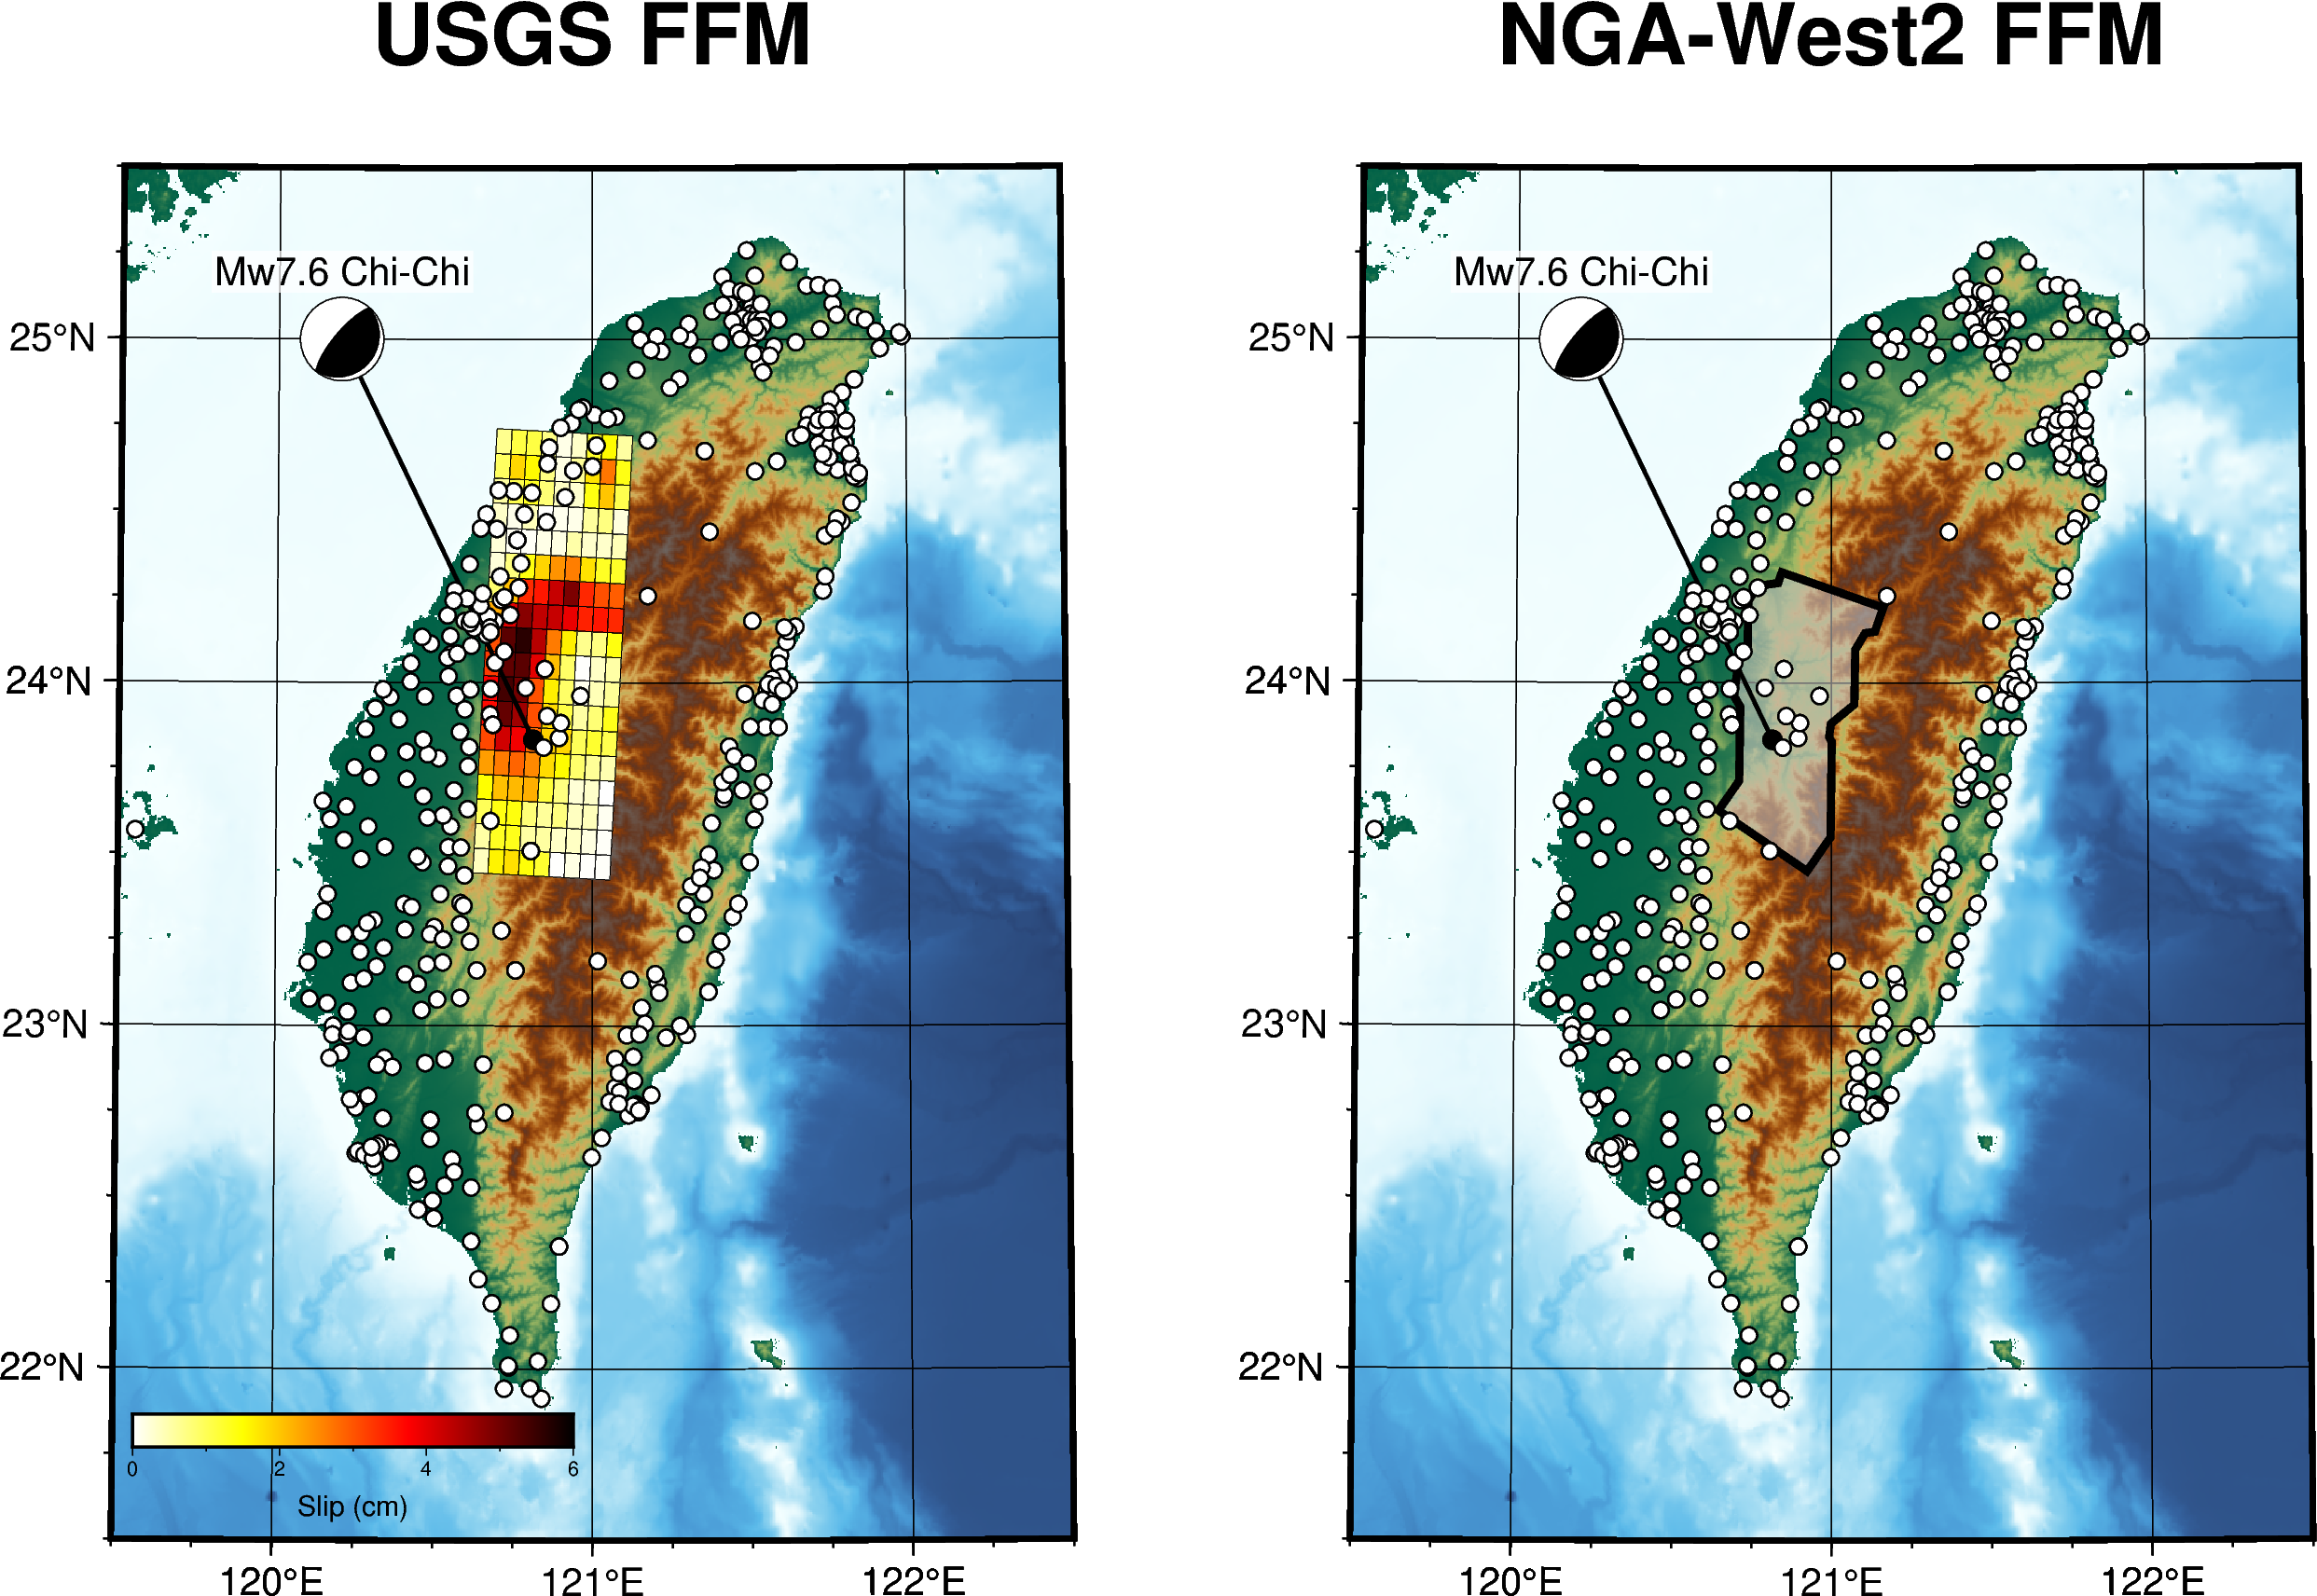

In [10]:
fig = pygmt.Figure()

region = [119.5, 122.5, 21.5, 25.5]
proj = "T121/23.5/?"

grid = pygmt.datasets.load_earth_relief(resolution="15s", region=region)
pygmt.makecpt(cmap="geo", series=[-8000, 7000, 500], continuous=True, output="data/eleva.cpt")
pygmt.makecpt(cmap = "matlab/hot", reverse = True, series=[0, 6, 0.25], continuous=True, output="data/slip.cpt")

with fig.subplot(nrows=1, ncols=2, figsize=["20c", "15c"], margins = "1c"):

    with fig.set_panel(panel=0):

        fig.grdimage(grid=grid, region=region, projection=proj, cmap="data/eleva.cpt")
        fig.basemap(frame=["a2f1g1", '+tUSGS FFM'])

        fig.plot(
            data=fault_gdf,
            cmap="data/slip.cpt",
            fill="+z",               
            aspatial="Z=slip",        
            pen="0.1p,black"
        )

        fig.meca(spec=event.iloc[0,0:].to_dict(), scale="0.5c+f10p", labelbox="white@30", offset="+p1p,black+s0.15c")
        fig.plot(x=df_chichi["Station Longitude"], y=df_chichi["Station Latitude"], style="c0.15c", fill="white", pen="0.5p,black")

        fig.colorbar(cmap="data/slip.cpt", frame=['x+lSlip (cm)', 'y'], position="jBL+w4c/0.3c+o0.2c/0.85c+h")

    with fig.set_panel(panel=1):

        fig.grdimage(grid=grid, region=region, projection=proj, cmap="data/eleva.cpt")
        fig.basemap(frame=["a2f1g1", '+tNGA-West2 FFM'])

        fig.plot(
                data=rupture,
                pen="2p,black", 
                fill = "grey@40"
        )

        fig.meca(spec=event.iloc[0,0:].to_dict(), scale="0.5c+f10p", labelbox="white@30", offset="+p1p,black+s0.15c")
        fig.plot(x=df_chichi["Station Longitude"], y=df_chichi["Station Latitude"], style="c0.15c", fill="white", pen="0.5p,black")

fig.show(width=1200)

# 5. Path parameters

## 5.1. Complex faulting: 1999 $M_{W}7.6$ Chi-Chi Earthquake 

In [11]:
import numpy as np

from openquake.hazardlib.geo import Point, Mesh
from openquake.hazardlib.geo.geodetic import geodetic_distance
from openquake.hazardlib.geo.surface.complex_fault import ComplexFaultSurface
from openquake.hazardlib.geo.surface import PlanarSurface, MultiSurface
from openquake.hazardlib.const import StdDev
from openquake.hazardlib.imt import PGA, PGV, SA
from openquake.hazardlib.contexts import simple_cmaker
from openquake.hazardlib.geo.surface.gridded import GriddedSurface

# Import the four NGA-West GMM classes
from openquake.hazardlib.gsim.abrahamson_2014 import AbrahamsonEtAl2014
from openquake.hazardlib.gsim.boore_2014 import BooreEtAl2014
from openquake.hazardlib.gsim.campbell_bozorgnia_2014 import CampbellBozorgnia2014
from openquake.hazardlib.gsim.chiou_youngs_2014 import ChiouYoungs2014

Create a mesh with the location of points of interest (stations):

In [12]:
# Reading points
df_stations = pd.DataFrame()
df_stations['station'] = df_chichi['Station Name'].values
df_stations['lon'] = df_chichi['Station Longitude'].values
df_stations['lat'] = df_chichi['Station Latitude'].values
depth_site = np.zeros_like(df_stations['lon'] , dtype=float)

site_mesh = Mesh(
    np.array(df_stations['lon'].values), 
    np.array(df_stations['lat'].values), 
    np.array(depth_site)
)

Calculate $R_{epi}$ and $R_{hypo}$:

In [13]:
#lon_epi = event['longitude'].values
#lat_epi = event['latitude'].values
#depth_epi = event['depth'].values
lon_epi = 120.8200
lat_epi = 23.8500
depth_epi = 8


eq_point = Point(lon_epi, lat_epi, depth_epi)
df_stations['r_epi'] = eq_point.distance_to_mesh(site_mesh, with_depths=False)
df_stations['r_hypo'] = eq_point.distance_to_mesh(site_mesh, with_depths=True)
df_stations.head()

,station,lon,lat,r_epi,r_hypo
0,ALS,120.8052,23.5103,37.802971,38.640194
1,CHK,121.3653,23.0992,100.313846,100.632340
2,CHY002,120.4125,23.7192,43.940373,44.662695
3,CHY004,120.1715,23.6013,71.573484,72.019189
4,CHY006,120.5520,23.5815,40.444622,41.228236


Given the complexity of the fault, we will use `ComplexFaultSurface`. For simpler rupture we can use `PlanarSurface` or `Multisurface`. The `ComplexFaultSurface` expects a `top_trace` and a `bottom_trace` in parallel directions. `geojson` polygons form a closed loop, the lower boundary run backwards relative to the top points. `ComplexFaultSurface` requires a rectangular grid matrix. So, the top trace has to contains the same number of vertices that the bottom.

In [14]:
rupture_json

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'rupture type': 'rupture extent'},
   'geometry': {'type': 'MultiPolygon',
    'coordinates': [[[[120.642478, 23.628361, -0.0],
       [120.707727, 23.715326, -0.0],
       [120.710529, 23.930184, -0.0],
       [120.690914, 23.961407, -0.0],
       [120.704824, 24.064683, -0.0],
       [120.733646, 24.086398, -0.0],
       [120.735648, 24.237511, -0.0],
       [120.76467, 24.282945, -0.0],
       [120.82992, 24.291451, -0.0],
       [120.841928, 24.322575, -0.0],
       [121.164181, 24.218877, 20.0],
       [121.137243, 24.149497, 20.0],
       [121.106199, 24.145511, 20.0],
       [121.075093, 24.097032, 20.0],
       [121.072564, 23.93772, 20.0],
       [120.997336, 23.881225, 20.0],
       [120.992055, 23.842642, 20.0],
       [121.000739, 23.828741, 20.0],
       [120.996491, 23.550194, 20.0],
       [120.922396, 23.45173, 20.0],
       [120.642478, 23.628361, -0.0]]]]}}],
 'metadata': {'depth': 33.0,

In [15]:
from openquake.hazardlib.geo.mesh import RectangularMesh

polygon_coordinates = rupture_json['features'][0]['geometry']['coordinates'][0][0]
top_vertex = []
bottom_vertex = []

for lon, lat, depth in polygon_coordinates[:-1]: # Exclude last point because it close the polygon
    depth = np.abs(depth)
    if depth == 0:
        top_vertex.append((lon, lat, depth))
    else:
        bottom_vertex.append((lon, lat, depth))

bottom_vertex.reverse()

lons = np.array([[pt[0] for pt in top_vertex], [pt[0] for pt in bottom_vertex]])
lats = np.array([[pt[1] for pt in top_vertex], [pt[1] for pt in bottom_vertex]])
depths = np.array([[pt[2] for pt in top_vertex], [pt[2] for pt in bottom_vertex]])

fault_mesh_chi_chi = RectangularMesh(lons, lats, depths)
rupture_surface_chi_chi = ComplexFaultSurface(fault_mesh_chi_chi)

In [16]:
# Rrup and Rjb
df_stations['r_rup'] = rupture_surface_chi_chi.get_min_distance(site_mesh)
df_stations['r_jb'] = rupture_surface_chi_chi.get_joyner_boore_distance(site_mesh)
df_stations['rx'] = rupture_surface_chi_chi.get_rx_distance(site_mesh)
#Ztor 
df_stations['Ztor'] = rupture_surface_chi_chi.get_top_edge_depth()
df_stations

,station,lon,lat,r_epi,r_hypo,r_rup,r_jb,rx,Ztor
0,ALS,120.8052,23.5103,37.802971,38.640194,21.151382,1.416194,21.103672,0.0
1,CHK,121.3653,23.0992,100.313846,100.632340,63.024046,59.860497,94.148714,0.0
2,CHY002,120.4125,23.7192,43.940373,44.662695,25.505683,25.501325,-25.028012,0.0
3,CHY004,120.1715,23.6013,71.573484,72.019189,48.078938,48.078938,-37.899017,0.0
4,CHY006,120.5520,23.5815,40.444622,41.228236,10.589595,10.584628,-4.652117,0.0
...,...,...,...,...,...,...,...,...,...
415,TTN050,121.0293,22.6740,132.501610,132.742897,89.299344,87.167800,92.764980,0.0
416,TTN051,121.0168,23.1887,76.221640,76.640319,36.679241,30.788780,59.187908,0.0
417,WGK,120.5622,23.6862,31.937430,32.924147,10.402666,10.377090,-10.380726,0.0
418,WNT,120.6843,23.8783,14.153398,16.257880,6.355595,2.592843,-2.597831,0.0


## 5.2. Planar faulting: 2022 $M_{W}6.9$ Taitung, Taiwan Earthaquake

Information about the event **USGS**: https://earthquake.usgs.gov/earthquakes/eventpage/us7000i90q/executive

In [17]:
rupture_taitung = gpd.read_file("data/rupture_taitung.json")

with open('data/rupture_taitung.json', 'r') as file:
    rupture_taitung_json = json.load(file)
print(json.dumps(rupture_taitung_json, indent=3))


{
   "type": "FeatureCollection",
   "metadata": {
      "reference": "Source: USGS NEIC Rapid Finite FaultEvent ID: 7000i90qModel created: 2022-10-12 19:41:33",
      "id": "us7000i90q",
      "network": "USGS National Earthquake Information Center, PDE",
      "netid": "us",
      "productcode": "us7000i90q",
      "time": "2022-09-18T06:44:13.000000Z",
      "lat": 23.138,
      "lon": 121.3439,
      "depth": 10.0,
      "mag": 6.9,
      "locstring": "90 km E of Yujing, Taiwan, TW",
      "mech": "ALL",
      "rake": 0.0
   },
   "features": [
      {
         "type": "Feature",
         "properties": {
            "rupture type": "rupture extent"
         },
         "geometry": {
            "type": "MultiPolygon",
            "coordinates": [
               [
                  [
                     [
                        121.37,
                        23.44,
                        0.0
                     ],
                     [
                        121.2,
          

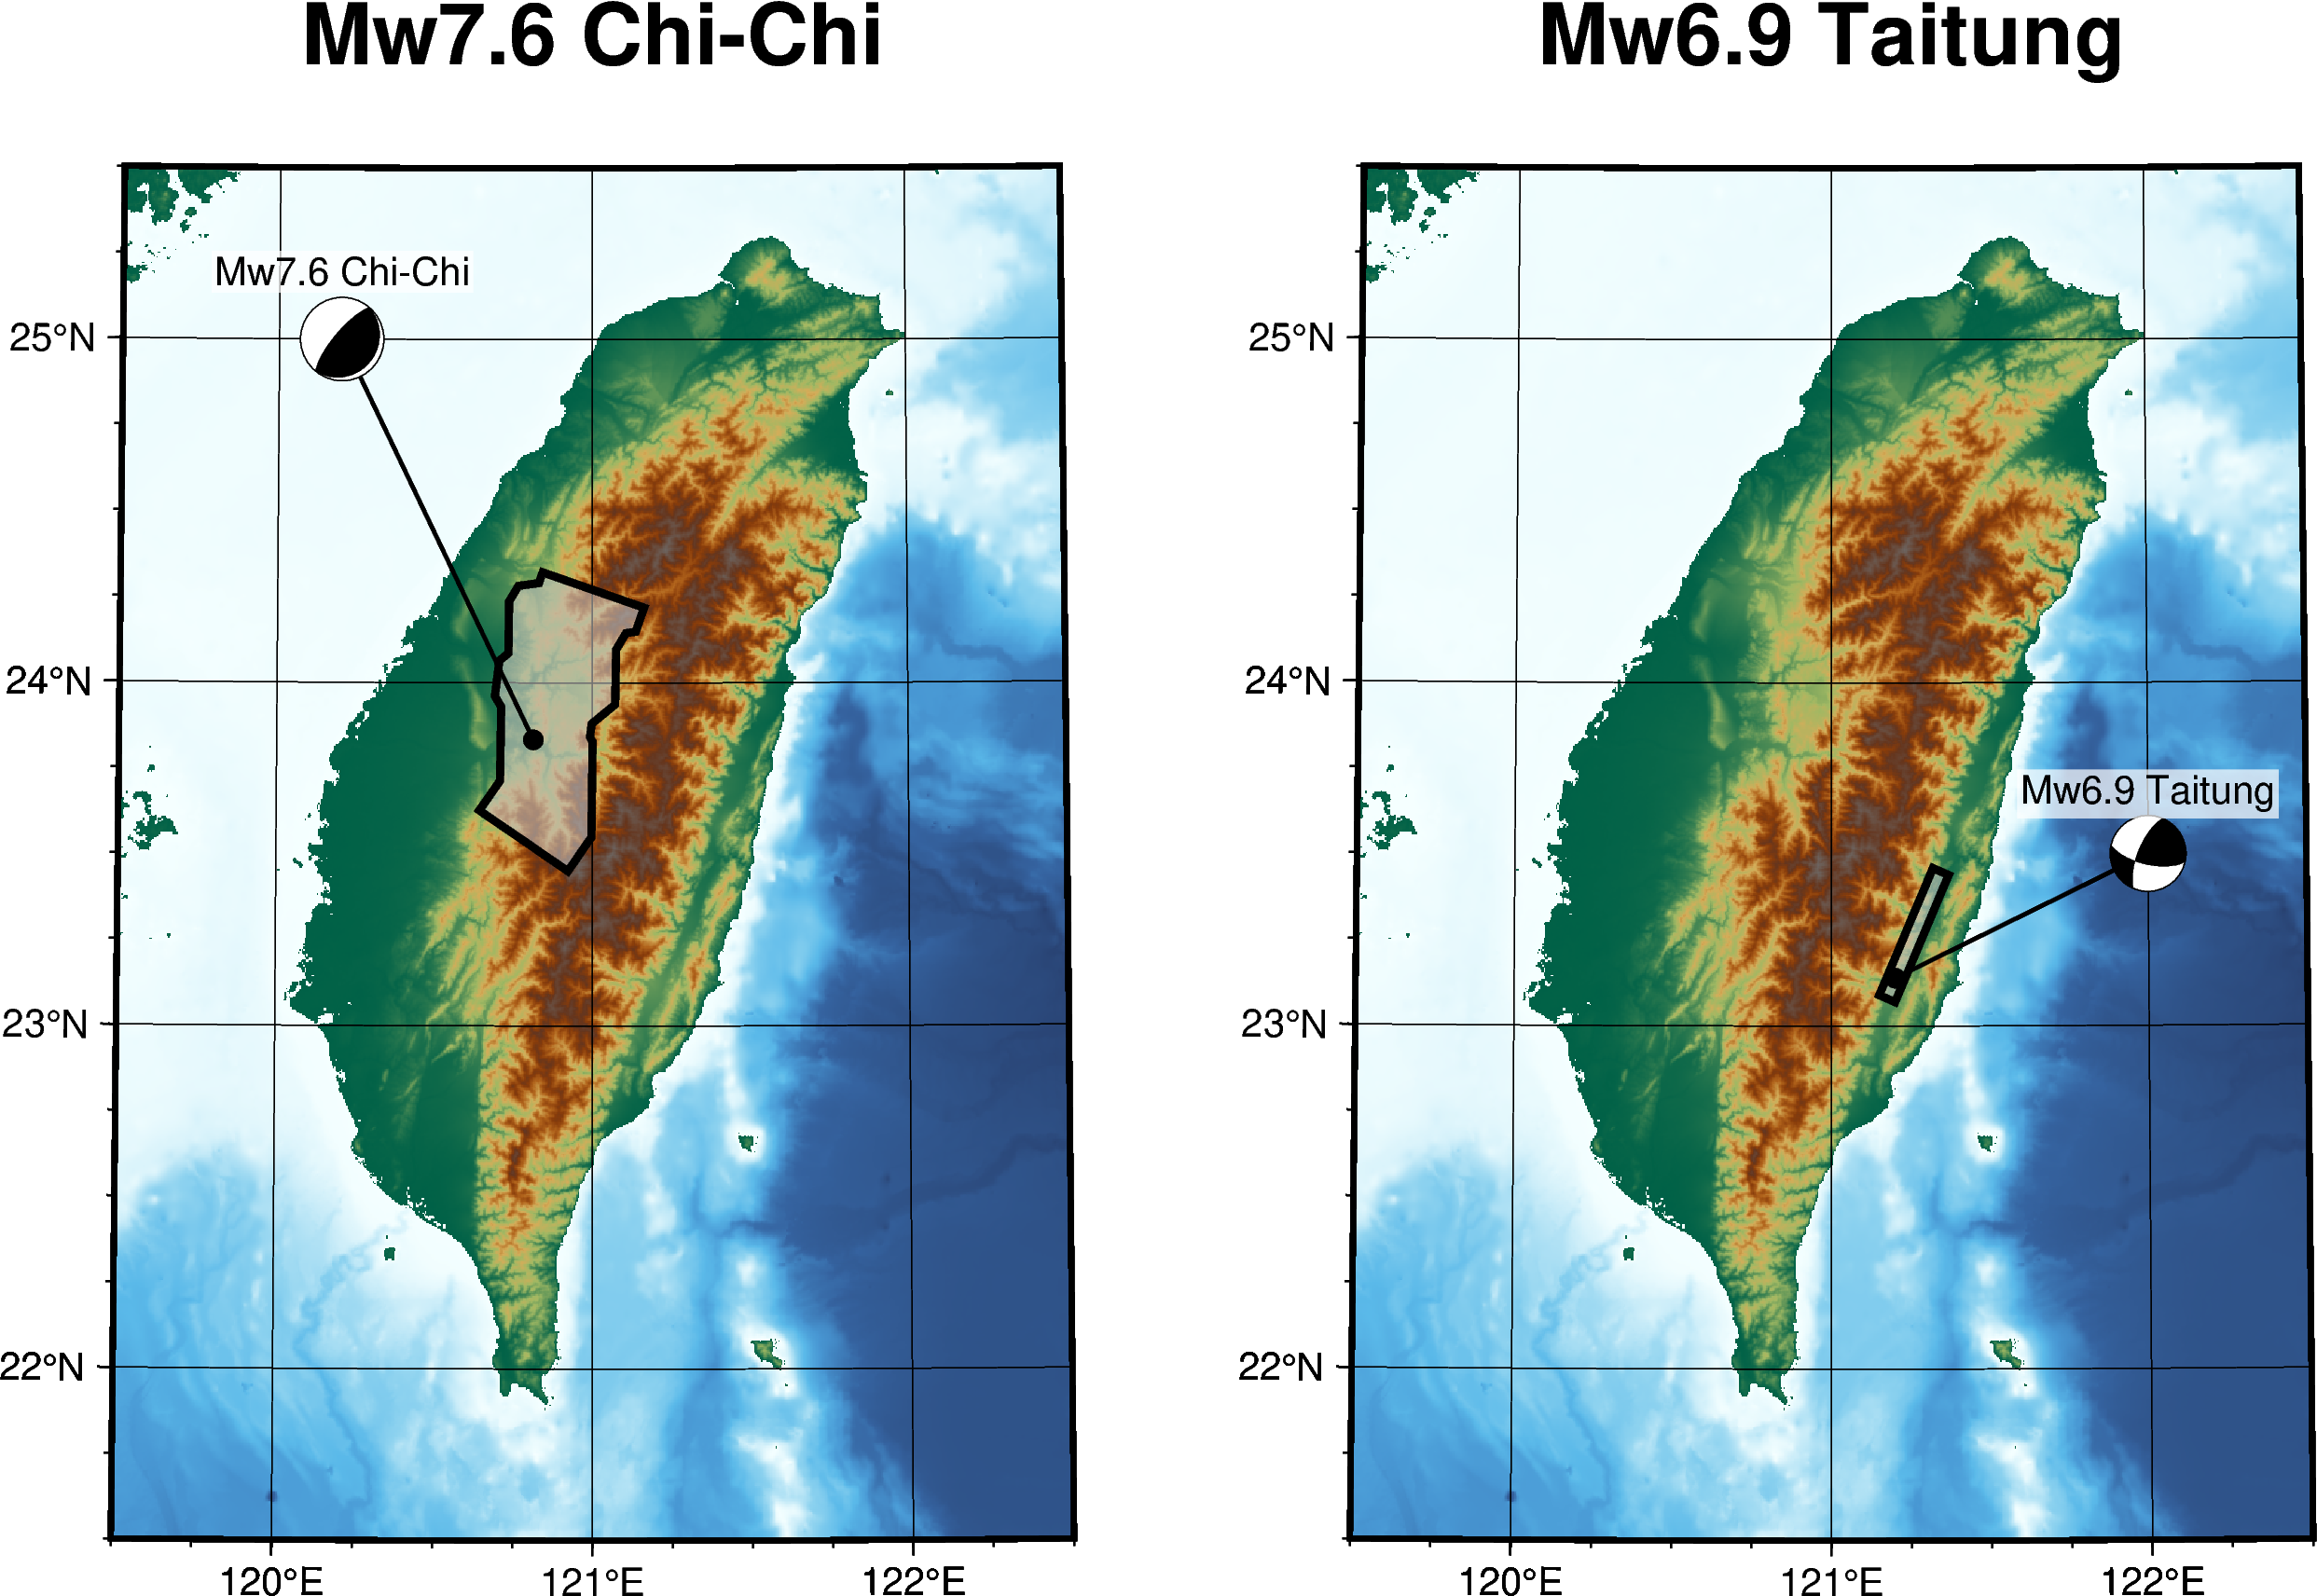

In [109]:
fig = pygmt.Figure()

region = [119.5, 122.5, 21.5, 25.5]
proj = "T121/23.5/?"

with fig.subplot(nrows=1, ncols=2, figsize=["20c", "15c"], margins = "1c"):

    with fig.set_panel(panel=0):

        fig.grdimage(grid=grid, region=region, projection=proj, cmap="data/eleva.cpt")
        fig.basemap(frame=["a2f1g1", '+tMw7.6 Chi-Chi'])
        fig.plot(data=rupture, pen="2p,black", fill = "grey@40")
        fig.meca(spec=event.iloc[0,0:].to_dict(), scale="0.5c+f10p", labelbox="white@30", offset="+p1p,black+s0.15c")

    with fig.set_panel(panel=1):

        fig.grdimage(grid=grid, region=region, projection=proj, cmap="data/eleva.cpt")
        fig.basemap(frame=["a2f1g1", '+tMw6.9 Taitung'])
        fig.plot(data=rupture_taitung, pen="2p,black", fill = "grey@40")
        fig.meca(spec=event.iloc[1,0:].to_dict(), scale="0.5c+f10p", labelbox="white@30", offset="+p1p,black+s0.15c")

fig.show(width=1200)

Note the difference in the rupture area between a $M_{W}7.6$ (3462 km<sup>2</sup>) and $M_{W}6.9$ (672 km<sup>2</sup>). We can define the planar surface using the corner point coordinates in the following order: top-left, top-right, bottom-right, bottom-left

In [85]:
polygon_coordinates = rupture_taitung_json['features'][0]['geometry']['coordinates'][0][0]

points = []
for lon, lat, depth in polygon_coordinates[:-1]:  # Exclude last point because it close the polygon
    points.append(Point(lon, lat, depth))
rupture_surface_taitung = PlanarSurface.from_corner_points(points[0], points[1], points[2], points[3])

In [86]:
print(rupture_surface_taitung.get_min_distance(site_mesh))

[5.24246093e+01 1.43151234e+01 9.73407753e+01 1.14829209e+02
 7.86130980e+01 1.00831527e+02 7.44776378e+01 1.06285694e+02
 6.38426847e+01 8.27269406e+01 1.03779224e+02 9.21999410e+01
 7.07694614e+01 7.18894991e+01 9.10611266e+01 8.10052020e+01
 9.04886221e+01 1.00799623e+02 1.14149374e+02 7.58162717e+01
 8.21592209e+01 1.02782846e+02 1.08190051e+02 7.67944992e+01
 7.30777189e+01 8.64764062e+01 9.53559738e+01 6.85995666e+01
 6.63748045e+01 1.06748514e+02 8.24251807e+01 8.46729918e+01
 7.98643938e+01 7.12069153e+01 9.02270055e+01 9.30555775e+01
 7.71739033e+01 8.64878450e+01 1.08398408e+02 9.41621069e+01
 6.68087678e+01 7.29443441e+01 8.42088597e+01 8.59259720e+01
 9.91198679e+01 1.00242655e+02 1.00793024e+02 9.61108592e+01
 1.01693896e+02 5.24246093e+01 1.11689772e+02 9.53697277e+01
 6.58986405e+01 6.76797675e+01 7.17794519e+01 1.08232352e+02
 6.51595253e+01 7.33995381e+01 8.01217130e+01 9.83506974e+01
 9.42678452e+01 1.19308279e+02 1.09029669e+02 9.55220935e+01
 9.00954943e+01 8.508819

# 6. Site parameters

In [87]:
# Site parameters
df_stations['Vs30'] = df_chichi['Vs30 (m/s) selected for analysis'].values
df_stations['Z1'] = df_chichi['Northern CA/Southern CA - H11 Z1 (m)'].values
df_stations

,station,lon,lat,r_epi,r_hypo,r_rup,r_jb,rx,Ztor,Vs30,Z1
0,ALS,120.8052,23.5103,37.802971,38.640194,21.151382,1.416194,21.103672,0.0,553.43,-999.0
1,CHK,121.3653,23.0992,100.313846,100.632340,63.024046,59.860497,94.148714,0.0,424.57,-999.0
2,CHY002,120.4125,23.7192,43.940373,44.662695,25.505683,25.501325,-25.028012,0.0,235.13,-999.0
3,CHY004,120.1715,23.6013,71.573484,72.019189,48.078938,48.078938,-37.899017,0.0,271.30,-999.0
4,CHY006,120.5520,23.5815,40.444622,41.228236,10.589595,10.584628,-4.652117,0.0,438.19,-999.0
...,...,...,...,...,...,...,...,...,...,...,...
415,TTN050,121.0293,22.6740,132.501610,132.742897,89.299344,87.167800,92.764980,0.0,573.04,-999.0
416,TTN051,121.0168,23.1887,76.221640,76.640319,36.679241,30.788780,59.187908,0.0,665.20,-999.0
417,WGK,120.5622,23.6862,31.937430,32.924147,10.402666,10.377090,-10.380726,0.0,258.89,-999.0
418,WNT,120.6843,23.8783,14.153398,16.257880,6.355595,2.592843,-2.597831,0.0,511.18,-999.0


Note that `-999` means N/A in NGA-West2 database. 

In [88]:
df_stations = df_stations.replace(-999, np.nan)
df_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   station  420 non-null    object 
 1   lon      420 non-null    float64
 2   lat      420 non-null    float64
 3   r_epi    420 non-null    float64
 4   r_hypo   420 non-null    float64
 5   r_rup    420 non-null    float64
 6   r_jb     420 non-null    float64
 7   rx       420 non-null    float64
 8   Ztor     420 non-null    float64
 9   Vs30     420 non-null    float64
 10  Z1       24 non-null     float64
dtypes: float64(10), object(1)
memory usage: 36.2+ KB


What happend with sites without $V_{S30}$? Comment Heath et al. option: https://apps.usgs.gov/earthquakes/vs30/

Following CY14, we will use a relationship between $Z_{1.0}$ and $V_{S30}$ for non-Japan regions:

$$\ln(Z_{1.0}) = -\frac{7.15}{4} \ln\left(\frac{V_{S30}^4 + 571^4}{1360^4+571^4}\right)$$

In [89]:
df_stations["Z1"] = np.where(df_stations["Z1"].isna(), np.round(np.exp(-7.15/4*np.log((df_stations["Vs30"]**4+571**4)/(1360**4+571**4))),1), df_stations["Z1"])
df_stations.head()

,station,lon,lat,r_epi,r_hypo,r_rup,r_jb,rx,Ztor,Vs30,Z1
0,ALS,120.8052,23.5103,37.802971,38.640194,21.151382,1.416194,21.103672,0.0,553.43,168.9
1,CHK,121.3653,23.0992,100.313846,100.632340,63.024046,59.860497,94.148714,0.0,424.57,324.8
2,CHY002,120.4125,23.7192,43.940373,44.662695,25.505683,25.501325,-25.028012,0.0,235.13,497.3
3,CHY004,120.1715,23.6013,71.573484,72.019189,48.078938,48.078938,-37.899017,0.0,271.30,478.7
4,CHY006,120.5520,23.5815,40.444622,41.228236,10.589595,10.584628,-4.652117,0.0,438.19,307.2


# 7. Predictions using GMMs

## 7.1. BSSA14

In [90]:
from openquake.hazardlib.gsim.boore_2014 import BooreEtAl2014
from openquake.hazardlib.imt import PGA, PGV, SA
from openquake.hazardlib.contexts import simple_cmaker


In [91]:
# GMM
gsim = BooreEtAl2014()

# Define IMTs 
imts = [PGA(), PGV()]

periods = [0.02,0.04,0.08,0.1,0.2,0.4,0.8,1,2,3]
for T in periods:
    imts.append(SA(T))
imt_strings = [str(imt) for imt in imts]

In [92]:
n = len(df_stations)
mag = np.full(n,event['magnitude'][0])

# Setup Context Maker for ALL IMTs
cmaker = simple_cmaker(
    [gsim], imt_strings, mags=["%2.2f" % m for m in mag]
)

ctx = cmaker.new_ctx(n)
# Source parameters
ctx["mag"] = mag 
ctx["rake"] = np.full(n, event['rake'][0])
# Path parameters
ctx["rjb"] = df_stations['r_jb']
# Site parameters
ctx["vs30"] = df_stations['Vs30']

# Run OpenQuake calculation
means, sigmas, taus, phis = cmaker.get_mean_stds([ctx])

# Extract results for each IMT
predicted_data = []

for imt_idx, imt_str in enumerate(imt_strings):
    # Extract arrays for the first GSIM (index 0) and current IMT
    mean_val = means[0][imt_idx]
    sigma_tot = sigmas[0][imt_idx]
    tau = taus[0][imt_idx]
    phi = phis[0][imt_idx]
    
    # Store results row-by-row or append to a structural dataframe
    df_imt = pd.DataFrame({
        'station': df_stations['station'],
        'rjb': df_stations['r_jb'],
        'Vs30': df_stations['Vs30'],
        'imt': imt_str,
        'mean_log': mean_val,
        'sigma': sigma_tot,
        'tau': tau,
        'phi': phi
    })
    predicted_data.append(df_imt)

# Combine all IMT data into a single master DataFrame
df_BSSA14 = pd.concat(predicted_data, ignore_index=True)
#df_results.to_csv('data/BSSA14_soil.csv', index=False)
print(df_BSSA14.head())

  station        rjb    Vs30  imt  mean_log     sigma    tau       phi
0     ALS   1.416194  553.43  PGA -0.626004  0.605086  0.348  0.495000
1     CHK  59.860497  424.57  PGA -2.293809  0.605086  0.348  0.495000
2  CHY002  25.501325  235.13  PGA -1.486988  0.557631  0.348  0.435716
3  CHY004  48.078938  271.30  PGA -1.940559  0.585239  0.348  0.470532
4  CHY006  10.584628  438.19  PGA -1.075810  0.605086  0.348  0.495000


Note that $\phi$ is not constant. BSSA14 model intraevent residuals include dependence on magnitude, degree of nonlinear soil response

## 7.2. CY14

In [93]:
from openquake.hazardlib.gsim.chiou_youngs_2014 import ChiouYoungs2014

In [94]:
# GMM
gsim = ChiouYoungs2014()

# Setup Context Maker for ALL IMTs
cmaker = simple_cmaker(
    [gsim], imt_strings, mags=["%2.2f" % m for m in mag]
)

# Context maker
ctx2 = cmaker.new_ctx(n)
# Source parameters
ctx2["mag"] = mag 
ctx2["dip"] = np.full(n, event['dip'][0])
ctx2["rake"] = np.full(n, event['rake'][0])
ctx2["ztor"] = df_stations['Ztor']
# Path parameters
ctx2["rjb"] = df_stations['r_jb']
ctx2["rrup"] = df_stations["r_rup"]
ctx2["rx"] = df_stations["r_rup"]
# Site parameters
ctx2["vs30"] = df_stations['Vs30']
ctx2["z1pt0"] = df_stations['Z1']

# Run OpenQuake calculation
means, sigmas, taus, phis = cmaker.get_mean_stds([ctx2])

# Extract results for each IMT
predicted_data = []

for imt_idx, imt_str in enumerate(imt_strings):
    # Extract arrays for the first GSIM (index 0) and current IMT
    mean_val = means[0][imt_idx]
    sigma_tot = sigmas[0][imt_idx]
    tau = taus[0][imt_idx]
    phi = phis[0][imt_idx]
    
    # Store results row-by-row or append to a structural dataframe
    df_imt = pd.DataFrame({
        'station': df_stations['station'],
        'rrup': df_stations['r_rup'],
        'Vs30': df_stations['Vs30'],
        'imt': imt_str,
        'mean_log': mean_val,
        'sigma': sigma_tot,
        'tau': tau,
        'phi': phi
    })
    predicted_data.append(df_imt)

# Combine all IMT data into a single master DataFrame
df_CY14 = pd.concat(predicted_data, ignore_index=True)
#df_results.to_csv('data/CY14_soil.csv', index=False)
print(df_CY14.head())


  station       rrup    Vs30  imt  mean_log     sigma       tau       phi
0     ALS  21.151382  553.43  PGA -1.140601  0.558648  0.253542  0.497800
1     CHK  63.024046  424.57  PGA -2.170382  0.554235  0.250392  0.494450
2  CHY002  25.505683  235.13  PGA -1.338048  0.494773  0.206235  0.449741
3  CHY004  48.078938  271.30  PGA -1.820990  0.523149  0.227749  0.470972
4  CHY006  10.589595  438.19  PGA -0.817027  0.545646  0.244217  0.487942


# 8. Comparison of model prediction with observed ground motions

## 8.1. Residual calculation

In [95]:
cols_name = ["Station Name","PGA (g)", "PGV (cm/sec)", "T0.020S","T0.040S","T0.080S","T0.100S","T0.200S","T0.400S","T0.800S","T1.000S","T2.000S","T3.000S"]
observed_data = df_chichi[cols_name].reset_index(drop=True)
# Renaming the columns
observed_data.columns = ['station'] + np.unique(df_CY14['imt']).tolist()
observed_data.head()

,station,PGA,PGV,SA(0.02),SA(0.04),SA(0.08),SA(0.1),SA(0.2),SA(0.4),SA(0.8),SA(1.0),SA(2.0),SA(3.0)
0,ALS,-999.000000,-999.0000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
1,CHK,-999.000000,-999.0000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
2,CHY002,0.097979,16.6140,0.102345,0.130342,0.319161,0.386845,0.276142,0.154477,0.116557,0.102835,0.050444,0.037800
3,CHY004,0.039923,6.1297,0.044048,0.092111,0.079819,0.085761,0.072829,0.064479,0.057692,0.043760,0.027648,0.033450
4,CHY006,0.215410,21.9090,0.225772,0.288924,0.380963,0.569679,0.301662,0.323483,0.207968,0.254661,0.188298,0.112522


In [96]:
observed_data = observed_data.replace(-999, np.nan)
observed_data.head()

,station,PGA,PGV,SA(0.02),SA(0.04),SA(0.08),SA(0.1),SA(0.2),SA(0.4),SA(0.8),SA(1.0),SA(2.0),SA(3.0)
0,ALS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHY002,0.097979,16.6140,0.102345,0.130342,0.319161,0.386845,0.276142,0.154477,0.116557,0.102835,0.050444,0.037800
3,CHY004,0.039923,6.1297,0.044048,0.092111,0.079819,0.085761,0.072829,0.064479,0.057692,0.043760,0.027648,0.033450
4,CHY006,0.215410,21.9090,0.225772,0.288924,0.380963,0.569679,0.301662,0.323483,0.207968,0.254661,0.188298,0.112522


In [81]:
observed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   station   420 non-null    object 
 1   PGA       399 non-null    float64
 2   PGV       399 non-null    float64
 3   SA(0.02)  399 non-null    float64
 4   SA(0.04)  399 non-null    float64
 5   SA(0.08)  399 non-null    float64
 6   SA(0.1)   399 non-null    float64
 7   SA(0.2)   399 non-null    float64
 8   SA(0.4)   399 non-null    float64
 9   SA(0.8)   399 non-null    float64
 10  SA(1.0)   399 non-null    float64
 11  SA(2.0)   399 non-null    float64
 12  SA(3.0)   399 non-null    float64
dtypes: float64(12), object(1)
memory usage: 42.8+ KB


In [97]:
# Melt data in format
obs_df = observed_data.melt(
    id_vars=['station'], 
    var_name='imt', 
    value_name='obs'
)
obs_df

,station,imt,obs
0,ALS,PGA,NaN
1,CHK,PGA,NaN
2,CHY002,PGA,0.097979
3,CHY004,PGA,0.039923
4,CHY006,PGA,0.215410
...,...,...,...
5035,TTN050,SA(3.0),0.007544
5036,TTN051,SA(3.0),0.012354
5037,WGK,SA(3.0),NaN
5038,WNT,SA(3.0),NaN


In [98]:
obs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   station  5040 non-null   object 
 1   imt      5040 non-null   object 
 2   obs      4788 non-null   float64
dtypes: float64(1), object(2)
memory usage: 118.2+ KB


In [99]:
df_BSSA14['obs_log'] = np.log(obs_df['obs'])
df_CY14['obs_log'] = np.log(obs_df['obs'])

# Remove NaN
df_BSSA14 = df_BSSA14.dropna().copy().reset_index(drop=True)
df_CY14 = df_CY14.dropna().copy().reset_index(drop=True)



In [100]:

# Remove sites outside the applicability range
# BSSA14
BSSA14 = df_BSSA14[
    (df_BSSA14['rjb']<=400) &
    (df_BSSA14['Vs30'] >= 150) & 
    (df_BSSA14['Vs30'] <= 1500)
    ].copy().reset_index(drop=True)

# CY14
CY14 = df_CY14[
    (df_CY14['rrup']<=300) &
    (df_CY14['Vs30'] >= 180) & 
    (df_CY14['Vs30'] <= 1500)
    ].copy().reset_index(drop=True)

In [101]:
np.log(obs_df['obs']).info()

<class 'pandas.core.series.Series'>
RangeIndex: 5040 entries, 0 to 5039
Series name: obs
Non-Null Count  Dtype  
--------------  -----  
4788 non-null   float64
dtypes: float64(1)
memory usage: 39.5 KB


In [102]:
# Residuals
BSSA14['res_tot'] = BSSA14['mean_log'] - BSSA14['obs_log']
CY14['res_tot'] = CY14['mean_log'] - CY14['obs_log']
BSSA14.head()

,station,rjb,Vs30,imt,mean_log,sigma,tau,phi,obs_log,res_tot
0,CHY002,25.501325,235.13,PGA,-1.486988,0.557631,0.348,0.435716,-2.323002,0.836014
1,CHY004,48.078938,271.30,PGA,-1.940559,0.585239,0.348,0.470532,-3.220803,1.280244
2,CHY006,10.584628,438.19,PGA,-1.075810,0.605086,0.348,0.495000,-1.535212,0.459402
3,CHY008,41.239152,210.73,PGA,-1.776661,0.549299,0.348,0.425000,-2.606410,0.829749
4,CHY010,20.625678,538.69,PGA,-1.540536,0.605086,0.348,0.495000,-2.081844,0.541309


In [103]:
# Statistics for each IM
stats_BSSA14 = BSSA14.groupby('imt')['res_tot'].agg(['count','mean','std','min','max']).reset_index()
stats_CY14 = CY14.groupby('imt')['res_tot'].agg(['count','mean','std','min','max']).reset_index()
print(stats_BSSA14)


         imt  count      mean       std       min       max
0        PGA    397  1.107128  0.444599 -0.784567  2.468112
1        PGV    397  0.364986  0.521331 -1.021649  1.845310
2   SA(0.02)    397  1.060594  0.448718 -1.045683  2.426849
3   SA(0.04)    397  0.967218  0.487512 -1.289741  2.401606
4   SA(0.08)    397  0.953713  0.576466 -1.441542  2.553668
5    SA(0.1)    397  1.010386  0.567972 -1.356630  2.595151
6    SA(0.2)    397  1.174425  0.495992 -0.186308  2.837138
7    SA(0.4)    397  1.121358  0.530362 -0.646822  2.648079
8    SA(0.8)    397  0.728161  0.561458 -1.285643  1.931216
9    SA(1.0)    397  0.610329  0.583567 -1.303362  2.077038
10   SA(2.0)    397  0.311161  0.611684 -1.420741  1.812760
11   SA(3.0)    397  0.241830  0.645381 -1.399355  2.464211


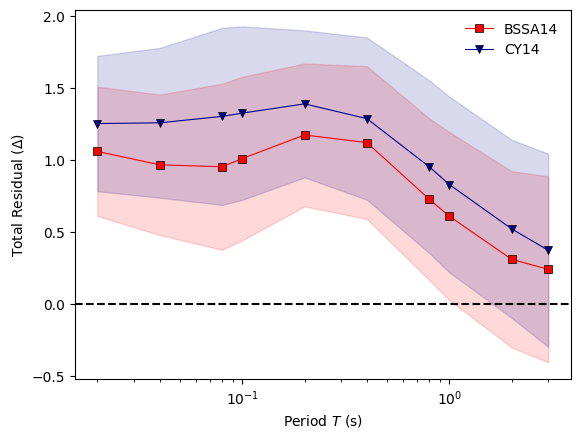

In [104]:
import matplotlib.pyplot as plt

# BSSA14
plt.plot(periods, stats_BSSA14['mean'].iloc[2:], 
         color='red', marker='s', markersize=6, markeredgecolor='black', 
         markeredgewidth=0.5, linewidth=0.8, label='BSSA14', zorder=3)
plt.fill_between(periods, stats_BSSA14['mean'].iloc[2:] - stats_BSSA14['std'].iloc[2:], stats_BSSA14['mean'].iloc[2:] + stats_BSSA14['std'].iloc[2:],
        color='red', alpha=0.15, zorder=2)
# CY14
plt.plot(periods, stats_CY14['mean'].iloc[2:], 
         color='darkblue', marker='v', markersize=6, markeredgecolor='black',
         markeredgewidth=0.5, linewidth=0.8, label='CY14', zorder=3)
plt.fill_between(periods, stats_CY14['mean'].iloc[2:] - stats_CY14['std'].iloc[2:], stats_CY14['mean'].iloc[2:] + stats_CY14['std'].iloc[2:], 
                 color='darkblue', alpha=0.15, zorder=2
                 )

# General settings
plt.xscale('log')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Period $T$ (s)')
plt.ylabel('Total Residual ($\Delta$)')
plt.legend(loc='upper right', frameon=False)
plt.show()

## 8.2. Scoring method: LLH

In [105]:
from scipy.stats import norm

In [106]:
# BSSA14
BSSA14['lik'] = norm.pdf(BSSA14['obs_log'], loc=BSSA14['mean_log'], scale=BSSA14['sigma'])
BSSA14['llh'] = np.log2(BSSA14['lik'])
stats_BSSA14['llh_score'] = -1*BSSA14.groupby('imt')['llh'].mean().to_numpy()
# CY14
CY14['lik'] = norm.pdf(CY14['obs_log'], loc=CY14['mean_log'], scale=CY14['sigma'])
CY14['llh'] = np.log2(CY14['lik'])
stats_CY14['llh_score'] = -1*CY14.groupby('imt')['llh'].mean().to_numpy()

print(stats_BSSA14)

         imt  count      mean       std       min       max  llh_score
0        PGA    397  1.107128  0.444599 -0.784567  2.468112   3.566693
1        PGV    397  0.364986  0.521331 -1.021649  1.845310   1.408030
2   SA(0.02)    397  1.060594  0.448718 -1.045683  2.426849   3.237299
3   SA(0.04)    397  0.967218  0.487512 -1.289741  2.401606   2.747877
4   SA(0.08)    397  0.953713  0.576466 -1.441542  2.553668   2.588771
5    SA(0.1)    397  1.010386  0.567972 -1.356630  2.595151   2.745579
6    SA(0.2)    397  1.174425  0.495992 -0.186308  2.837138   3.727943
7    SA(0.4)    397  1.121358  0.530362 -0.646822  2.648079   3.698006
8    SA(0.8)    397  0.728161  0.561458 -1.285643  1.931216   2.176503
9    SA(1.0)    397  0.610329  0.583567 -1.303362  2.077038   1.887546
10   SA(2.0)    397  0.311161  0.611684 -1.420741  1.812760   1.505989
11   SA(3.0)    397  0.241830  0.645381 -1.399355  2.464211   1.510812


In [108]:
print(stats_CY14)

         imt  count      mean       std       min       max  llh_score
0        PGA    388  1.268492  0.459057 -0.565612  2.618637   4.932796
1        PGV    388  0.478550  0.495123 -0.830842  1.895396   1.656583
2   SA(0.02)    388  1.253580  0.469826 -0.812544  2.616471   4.825715
3   SA(0.04)    388  1.258650  0.519829 -1.007727  2.682205   4.698822
4   SA(0.08)    388  1.303375  0.614585 -1.098753  2.903206   5.040262
5    SA(0.1)    388  1.325946  0.602472 -1.040319  2.911644   5.098322
6    SA(0.2)    388  1.390159  0.510408  0.066800  3.052151   5.052669
7    SA(0.4)    388  1.287981  0.563135 -0.535924  2.837151   4.373059
8    SA(0.8)    388  0.953408  0.599260 -1.060309  2.261199   2.888808
9    SA(1.0)    388  0.830185  0.609595 -1.052964  2.441045   2.503504
10   SA(2.0)    388  0.522260  0.618115 -1.173275  2.098502   1.789919
11   SA(3.0)    388  0.374268  0.670860 -1.350415  2.520948   1.683808


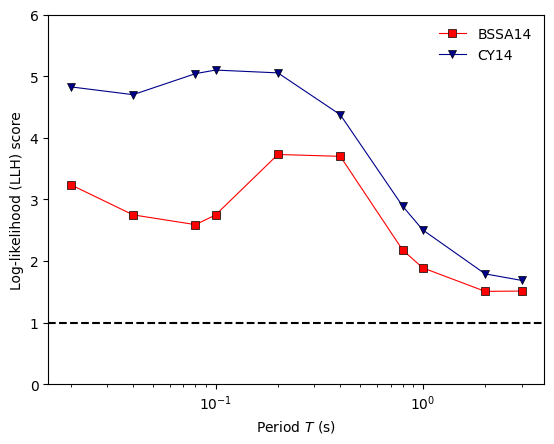

In [107]:
# BSSA14
plt.plot(periods, stats_BSSA14['llh_score'].iloc[2:], 
         color='red', marker='s', markersize=6, markeredgecolor='black', 
         markeredgewidth=0.5, linewidth=0.8, label='BSSA14', zorder=3)
# CY14
plt.plot(periods, stats_CY14['llh_score'].iloc[2:], 
         color='darkblue', marker='v', markersize=6, markeredgecolor='black',
         markeredgewidth=0.5, linewidth=0.8, label='CY14', zorder=3)


# General settings
plt.xscale('log')
plt.ylim([0,6])
plt.axhline(1, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Period $T$ (s)')
plt.ylabel('Log-likelihood (LLH) score')
plt.legend(loc='upper right', frameon=False)
plt.show()